<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/XGBOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


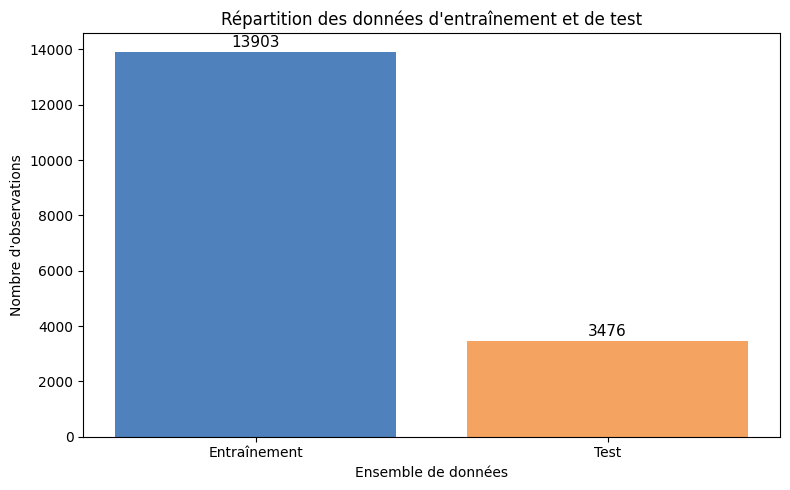

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the DataFrame first
df = pd.read_csv('/content/drive/MyDrive/PFE/base_plus_reelle_finale.csv', sep=';')
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")

# Nombre total d'observations
n = len(df)

# Répartition 80% / 20%
train = round(n * 0.8)
test = n - train

# Création du graphique
plt.figure(figsize=(8,5))
plt.bar(["Entraînement", "Test"], [train, test], color=["#4F81BD", "#F4A460"])

# Titre et axes
plt.title("Répartition des données d'entraînement et de test")
plt.xlabel("Ensemble de données")
plt.ylabel("Nombre d'observations")

# Afficher les valeurs sur les barres
for i, v in enumerate([train, test]):
    plt.text(i, v + n*0.01, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

# =========================
# 1) Charger la base source
# =========================
df = pd.read_csv('/content/drive/MyDrive/PFE/base_propre_corrigee.csv', sep=';')

# IMPORTANT : cette base se lit avec dayfirst=True
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

print("Dates invalides au départ :", df["date"].isna().sum())

# =========================
# 2) Nettoyage minimal
# =========================
df["jour_semaine"] = df["jour_semaine"].astype(str).str.lower().str.strip()
df["meteo"] = df["meteo"].astype(str).str.lower().str.strip()
df["saison"] = df["saison"].astype(str).str.lower().str.strip()

if "heure_num" not in df.columns:
    df["heure_num"] = (
        df["heure"].astype(str)
        .str.replace("h00", "", regex=False)
        .str.replace("H00", "", regex=False)
        .astype(int)
    )

# Sauvegarder les anciennes réservations
df["reservations_avant"] = df["reservations"].copy()
df["meteo_avant_patch"] = df["meteo"].copy()

# =========================
# 3) Correction du midi en semaine
#    (midi plus faible)
# =========================
def corriger_midi_semaine(row):
    heure = int(row["heure_num"])
    jour = str(row["jour_semaine"]).lower()
    meteo = str(row["meteo"]).lower()
    ferie = int(row["ferie"])
    evenement = int(row["is_special_event"])
    capacite = int(row["capacite_max"])
    reservations = int(row["reservations"])

    # Seulement lundi à vendredi, entre 12h et 14h, non férié, sans événement
    if jour in ["lundi", "mardi", "mercredi", "jeudi", "vendredi"] and 12 <= heure <= 14 and ferie == 0 and evenement == 0:

        # Version plus stricte
        if meteo in ["pluvieux", "orageux"]:
            plafond_pct = 25
        elif meteo == "nuageux":
            plafond_pct = 35
        elif meteo == "venteux":
            plafond_pct = 30
        elif meteo in ["ensoleillé", "ensoleille", "clair"]:
            plafond_pct = 40
        else:
            plafond_pct = 35

        plafond_res = int(round(capacite * plafond_pct / 100))
        reservations = min(reservations, plafond_res)

    return reservations

df["reservations"] = df.apply(corriger_midi_semaine, axis=1)

# =========================
# 4) Correction météo nuit
#    ensoleillé -> nuit_claire
# =========================
def est_nuit(heure, saison):
    heure = int(heure)
    saison = str(saison).strip().lower()

    if saison in ["été", "ete"]:
        return (heure < 6) or (heure >= 21)
    elif saison == "hiver":
        return (heure < 7) or (heure >= 18)
    elif saison in ["printemps", "automne"]:
        return (heure < 6) or (heure >= 19)
    else:
        return (heure < 6) or (heure >= 20)

mask_soleil_nuit = (
    df["meteo"].isin(["ensoleillé", "ensoleille"]) &
    df.apply(lambda row: est_nuit(row["heure_num"], row["saison"]), axis=1)
)

df.loc[mask_soleil_nuit, "meteo"] = "nuit_claire"

# =========================
# 5) Recalculer taux d’occupation
# =========================
df["taux_occupation"] = ((df["reservations"] / df["capacite_max"]) * 100).round(2)

# =========================
# 6) Colonnes utiles pour l’audit
# =========================
df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour_mois"] = df["date"].dt.day

string_to_num_jour_semaine = {
    "dimanche": 0,
    "lundi": 1,
    "mardi": 2,
    "mercredi": 3,
    "jeudi": 4,
    "vendredi": 5,
    "samedi": 6
}
df["jour_semaine_num"] = df["jour_semaine"].map(string_to_num_jour_semaine)

df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

# =========================
# 7) Vérifications rapides
# =========================
print("\n===== CONTRÔLE RAPIDE =====")
print("Dates invalides :", df["date"].isna().sum())
print("Lignes réservations modifiées :", (df["reservations"] != df["reservations_avant"]).sum())

mask_nuit_apres = (
    df["meteo"].isin(["ensoleillé", "ensoleille"]) &
    df.apply(lambda row: est_nuit(row["heure_num"], row["saison"]), axis=1)
)
print("Ensoleillé la nuit restant :", mask_nuit_apres.sum())

print("\nMoyenne des réservations par heure :")
print(df.groupby("heure_num")["reservations"].mean().sort_values(ascending=False))

# =========================
# 8) Sauvegarder la vraie base finale
# =========================
output_path = '/content/drive/MyDrive/PFE/base_plus_reelle_finale.csv'
df.to_csv(output_path, index=False, sep=';', date_format='%Y-%m-%d')

print("\n✅ Base finale sauvegardée :", output_path)

Dates invalides au départ : 0

===== CONTRÔLE RAPIDE =====
Dates invalides : 0
Lignes réservations modifiées : 1511
Ensoleillé la nuit restant : 0

Moyenne des réservations par heure :
heure_num
20    115.277473
19    106.501374
18     70.495879
21     64.549451
13     52.857339
11     47.799175
12     47.710165
17     45.704110
14     40.625514
16     35.769863
15     33.510288
10     28.689133
9      23.806052
22     22.434066
8      19.031637
23     12.776099
7       2.631362
6       1.652414
3       0.684362
2       0.660140
1       0.638122
4       0.635581
5       0.630404
0       0.622590
Name: reservations, dtype: float64

✅ Base finale sauvegardée : /content/drive/MyDrive/PFE/base_plus_reelle_finale.csv


In [12]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/PFE/base_plus_reelle_finale.csv', sep=';')
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")

print("Dimensions :", df.shape)
print("Dates invalides :", df["date"].isna().sum())
print(df.head())


Dimensions : (17379, 25)
Dates invalides : 0
        date  heure jour_semaine saison  ferie  nom_ferie  jour_ouvrable  \
0 2011-01-01  00h00       samedi  hiver      1  Nouvel An              0   
1 2011-01-01  01h00       samedi  hiver      1  Nouvel An              0   
2 2011-01-01  02h00       samedi  hiver      1  Nouvel An              0   
3 2011-01-01  03h00       samedi  hiver      1  Nouvel An              0   
4 2011-01-01  04h00       samedi  hiver      1  Nouvel An              0   

         meteo  temperature_c  humidite_pct  ...  taux_occupation  heure_num  \
0  nuit_claire           13.9            85  ...             20.0          0   
1  nuit_claire           13.1            84  ...             20.0          1   
2  nuit_claire           13.1            84  ...             20.0          2   
3  nuit_claire           13.9            80  ...             20.0          3   
4  nuit_claire           13.9            80  ...             20.0          4   

  reservations_av

In [13]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBRegressor

# =========================
# 1) Charger la base finale
# =========================
df = pd.read_csv('/content/drive/MyDrive/PFE/base_plus_reelle_finale.csv', sep=';')

# Parsing correct de la date
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")
df = df.dropna(subset=["date"])

# =========================
# 2) Préparer la date
# =========================
df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour_mois"] = df["date"].dt.day

# =========================
# 3) Préparer l'heure
# =========================
if "heure_num" not in df.columns:
    df["heure_num"] = df["heure"].astype(str).str.replace("h00", "", regex=False).astype(int)

if "heure_sin" not in df.columns:
    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)

if "heure_cos" not in df.columns:
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

# =========================
# 4) Mapping jour_semaine → numérique
# =========================
string_to_num_jour_semaine = {
    "dimanche": 0,
    "lundi": 1,
    "mardi": 2,
    "mercredi": 3,
    "jeudi": 4,
    "vendredi": 5,
    "samedi": 6
}

df["jour_semaine"] = df["jour_semaine"].astype(str).str.lower().str.strip()
df["jour_semaine_num"] = df["jour_semaine"].map(string_to_num_jour_semaine)

# =========================
# 5) Colonnes numériques
# =========================
numeric_cols = [
    "ferie", "jour_ouvrable", "temperature_c", "humidite_pct",
    "vent_kmh", "is_special_event", "capacite_max", "reservations"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remplacer texte vide
for col in ["nom_ferie", "nom_evenement", "meteo", "saison", "jour_semaine"]:
    if col in df.columns:
        df[col] = df[col].replace("", "Aucun").fillna("Aucun")

df["meteo"] = df["meteo"].astype(str).str.lower().str.strip()
df["saison"] = df["saison"].astype(str).str.lower().str.strip()

df = df.dropna(subset=["reservations"])

# ==========================================
# 6) Correction météo : "ensoleillé" = nuit
# ==========================================
def corriger_meteo_nuit(row):
    meteo = str(row["meteo"]).lower()
    heure = int(row["heure_num"])
    saison = str(row["saison"]).lower()

    if meteo == "ensoleillé":
        if saison == "été":
            if heure < 6 or heure >= 20:
                return "nuit_claire"
        elif saison == "hiver":
            if heure < 7 or heure >= 18:
                return "nuit_claire"
        elif saison in ["printemps", "automne"]:
            if heure < 6 or heure >= 19:
                return "nuit_claire"

    return row["meteo"]

df["meteo"] = df.apply(corriger_meteo_nuit, axis=1)

# =========================
# 7) Définir les features
# =========================
features = [
    "saison", "jour_semaine", "ferie", "nom_ferie", "jour_ouvrable",
    "meteo", "temperature_c", "humidite_pct", "vent_kmh",
    "is_special_event", "nom_evenement", "capacite_max",
    "annee", "mois", "jour_mois", "heure_sin", "heure_cos"
]

target = "reservations"

X = df[features].copy()
y = df[target].copy()

# =========================
# 8) One-hot encoding
# =========================
categorical_cols = ["saison", "jour_semaine", "nom_ferie", "meteo", "nom_evenement"]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

model_columns = X.columns.tolist()

# =========================
# 9) Train/test split chronologique
# =========================
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# =========================
# 10) Entraîner le modèle
# =========================
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# =========================
# 11) Prédictions
# =========================
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = np.maximum(0, y_pred_xgb)

# =========================
# 12) Configuration promo
# =========================
CFG_PROMO = {
    "promo_max": 30,
    "seuil_forte_demande_quantile": 0.75,
    "plafond": 30,
    "plancher": 0
}

def calcul_promo_dynamique(reservations_prevues, min_res, max_res, promo_max=30):
    if max_res == min_res:
        return 0

    ratio = (reservations_prevues - min_res) / (max_res - min_res)
    ratio = max(0, min(ratio, 1))
    promo = promo_max * (1 - ratio)

    if promo < 5:
        return 0

    return int(round(promo / 5) * 5)

# ==================================================
# 13) Nouvelle fonction promo : météo + jour férié
# ==================================================
def ajuster_promo_selon_contexte(
    promo_base, jour_semaine, heure, meteo, ferie,
    is_special_event, nom_evenement
):
    promo = promo_base
    meteo = str(meteo).lower()
    nom_evenement = str(nom_evenement).lower()

    # -------- JOUR / HEURE --------
    if jour_semaine == 1 and 9 <= heure <= 11:
        promo += 5

    if jour_semaine in [2, 3, 4] and 14 <= heure <= 17:
        promo += 5

    # ✅ Midi en semaine = plus faible → plus de promo
    if jour_semaine in [1, 2, 3, 4, 5] and 12 <= heure <= 14 and int(ferie) == 0:
        promo += 5

    if jour_semaine == 5 and 19 <= heure <= 22:
        promo -= 5

    if jour_semaine in [0, 6] and (12 <= heure <= 15 or 19 <= heure <= 21):
        promo -= 5

    # ================================
    # ✅ Nouvelle logique jour férié
    # ================================
    if int(ferie) == 1:

        # Cas férié + bonne météo
        meteo_bonne = ["ensoleillé", "ensoleille", "clair", "nuit_claire"]
        heures_bonnes = [12, 13, 14, 19, 20]

        if meteo in meteo_bonne and heure in heures_bonnes:
            promo += 5

        # Cas férié + mauvaise météo
        meteo_mauvaise = ["pluvieux", "nuageux", "venteux", "orageux"]

        if meteo in meteo_mauvaise:
            promo += 10

    # Événement spécial : on réduit la promo
    if int(is_special_event) == 1:
        mots_cles_evenement_fort = [
            "finale", "champions league", "ligue des champions",
            "concert", "festival", "match", "derby"
        ]

        if any(mot in nom_evenement for mot in mots_cles_evenement_fort):
            promo -= 10
        else:
            promo -= 5

    promo = max(CFG_PROMO["plancher"], min(promo, CFG_PROMO["plafond"]))

    if promo == 0:
        return 0

    return int(round(promo / 5) * 5)

def recommander_promo_finale(
    reservations_prevues, jour_semaine, heure, meteo,
    ferie, is_special_event, nom_evenement,
    min_res, max_res, seuil_forte_demande, promo_max=30
):
    if reservations_prevues >= seuil_forte_demande:
        return 0

    promo_base = calcul_promo_dynamique(
        reservations_prevues, min_res, max_res, promo_max
    )

    return ajuster_promo_selon_contexte(
        promo_base, jour_semaine, heure, meteo,
        ferie, is_special_event, nom_evenement
    )

# =========================
# 14) Générer la promo finale
# =========================
min_res = y_train.min()
max_res = y_train.max()
seuil_forte_demande = y_train.quantile(CFG_PROMO["seuil_forte_demande_quantile"])

jours_test = df.iloc[split_index:]["jour_semaine_num"].values
heures_test = df.iloc[split_index:]["heure_num"].values
meteo_test = df.iloc[split_index:]["meteo"].values
ferie_test = df.iloc[split_index:]["ferie"].values
is_special_event_test = df.iloc[split_index:]["is_special_event"].values
nom_evenement_test = df.iloc[split_index:]["nom_evenement"].values

promo_finale = [
    recommander_promo_finale(
        pred, jour, heure, meteo, ferie, is_evt, nom_evt,
        min_res, max_res, seuil_forte_demande, CFG_PROMO["promo_max"]
    )
    for pred, jour, heure, meteo, ferie, is_evt, nom_evt in zip(
        y_pred_xgb, jours_test, heures_test,
        meteo_test, ferie_test, is_special_event_test, nom_evenement_test
    )
]

# =========================
# 15) Tableau final
# =========================
mapping_jours = {
    0: "dimanche", 1: "lundi", 2: "mardi", 3: "mercredi",
    4: "jeudi", 5: "vendredi", 6: "samedi"
}

def format_heure(h):
    return f"{int(h):02d}h00"

resultats_modele = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "jour_nom": [mapping_jours[j] for j in jours_test],
    "heure_affichage": [format_heure(h) for h in heures_test],
    "meteo": meteo_test,
    "ferie": ferie_test,
    "nom_ferie": df.iloc[split_index:]["nom_ferie"].values,
    "is_special_event": is_special_event_test,
    "nom_evenement": df.iloc[split_index:]["nom_evenement"].values,
    "reservations_reelles": y_test.values,
    "reservations_prevues": np.round(y_pred_xgb, 2),
    "promo_finale": promo_finale
})

resultats_modele["promo_affichage"] = resultats_modele["promo_finale"].astype(str) + "%"

print(resultats_modele.head(200).to_string(index=False))

      date jour_nom heure_affichage       meteo  ferie  nom_ferie  is_special_event nom_evenement  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2012-08-07    mardi           12h00     nuageux      0      Aucun                 0         Aucun                    32             32.799999            25             25%
2012-08-07    mardi           13h00     nuageux      0      Aucun                 0         Aucun                    35             35.020000            25             25%
2012-08-07    mardi           14h00     nuageux      0      Aucun                 0         Aucun                    30             29.820000            30             30%
2012-08-07    mardi           15h00  ensoleillé      0      Aucun                 0         Aucun                    31             31.540001            30             30%
2012-08-07    mardi           16h00    pluvieux      0      Aucun                 0         Aucun                    25             23.36000